# Data Preprocessing - Cancer Risk Prediction Dataset

This notebook handles data loading, exploration, and preprocessing for the Cancer Risk dataset (1500 samples).

## 1. Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
import pickle
import warnings
warnings.filterwarnings('ignore')

## 2. Load Dataset

In [2]:
# Load the dataset
df = pd.read_csv('./data/The_Cancer_data_1500_V2.csv')

print(f"Dataset shape: {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")
print(f"\nFirst few rows:")
df.head()

Dataset shape: (1500, 9)

Columns: ['Age', 'Gender', 'BMI', 'Smoking', 'GeneticRisk', 'PhysicalActivity', 'AlcoholIntake', 'CancerHistory', 'Diagnosis']

First few rows:


,Age,Gender,BMI,Smoking,GeneticRisk,PhysicalActivity,AlcoholIntake,CancerHistory,Diagnosis
0,58,1,16.085313,0,1,8.146251,4.148219,1,1
1,71,0,30.828784,0,1,9.361630,3.519683,0,0
2,48,1,38.785084,0,2,5.135179,4.728368,0,1
3,34,0,30.040296,0,0,9.502792,2.044636,0,0
4,62,1,35.479721,0,0,5.356890,3.309849,0,1


## 3. Data Exploration

In [3]:
# Check for missing values
print("Missing values:")
print(df.isnull().sum())

print(f"\n\nDataset info:")
df.info()

Missing values:
Age                 0
Gender              0
BMI                 0
Smoking             0
GeneticRisk         0
PhysicalActivity    0
AlcoholIntake       0
CancerHistory       0
Diagnosis           0
dtype: int64


Dataset info:
<class 'pandas.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Age               1500 non-null   int64  
 1   Gender            1500 non-null   int64  
 2   BMI               1500 non-null   float64
 3   Smoking           1500 non-null   int64  
 4   GeneticRisk       1500 non-null   int64  
 5   PhysicalActivity  1500 non-null   float64
 6   AlcoholIntake     1500 non-null   float64
 7   CancerHistory     1500 non-null   int64  
 8   Diagnosis         1500 non-null   int64  
dtypes: float64(3), int64(6)
memory usage: 105.6 KB


Target distribution (Diagnosis):
Diagnosis
0    943
1    557
Name: count, dtype: int64

Percentage:
Diagnosis
0    62.866667
1    37.133333
Name: proportion, dtype: float64


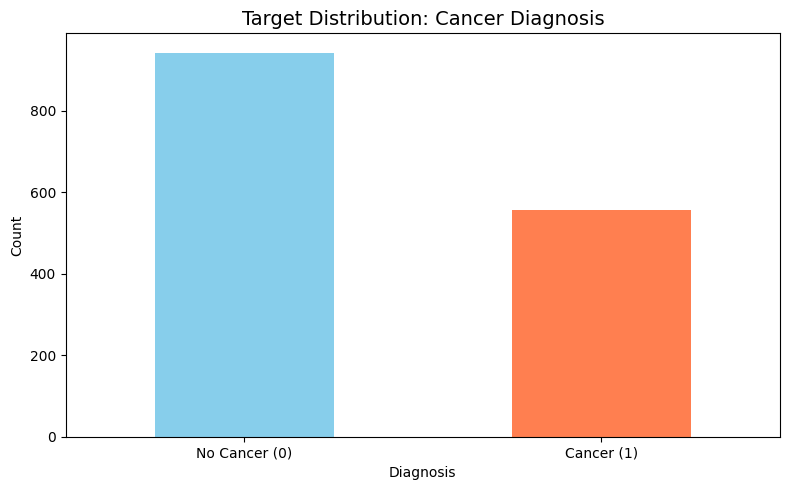

In [4]:
# Target distribution
print("Target distribution (Diagnosis):")
print(df['Diagnosis'].value_counts())
print(f"\nPercentage:")
print(df['Diagnosis'].value_counts(normalize=True) * 100)

# Visualize target distribution
plt.figure(figsize=(8, 5))
df['Diagnosis'].value_counts().plot(kind='bar', color=['skyblue', 'coral'])
plt.title('Target Distribution: Cancer Diagnosis', fontsize=14)
plt.xlabel('Diagnosis')
plt.ylabel('Count')
plt.xticks([0, 1], ['No Cancer (0)', 'Cancer (1)'], rotation=0)
plt.tight_layout()
plt.show()

In [5]:
# Statistical summary
print("Statistical summary:")
df.describe()

Statistical summary:


,Age,Gender,BMI,Smoking,GeneticRisk,PhysicalActivity,AlcoholIntake,CancerHistory,Diagnosis
count,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000
mean,50.320000,0.490667,27.513321,0.269333,0.508667,4.897929,2.417987,0.144000,0.371333
std,17.640968,0.500080,7.230012,0.443761,0.678895,2.866162,1.419318,0.351207,0.483322
min,20.000000,0.000000,15.000291,0.000000,0.000000,0.002410,0.001215,0.000000,0.000000
25%,35.000000,0.000000,21.483134,0.000000,0.000000,2.434609,1.210598,0.000000,0.000000
50%,51.000000,0.000000,27.598494,0.000000,0.000000,4.834316,2.382971,0.000000,0.000000
75%,66.000000,1.000000,33.850837,1.000000,1.000000,7.409896,3.585624,0.000000,1.000000
max,80.000000,1.000000,39.958688,1.000000,2.000000,9.994607,4.987115,1.000000,1.000000


## 4. Feature Engineering & Preprocessing

In [6]:
# Separate features and target
X = df.drop('Diagnosis', axis=1)
y = df['Diagnosis']

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"\nFeature columns ({len(X.columns)}):")
print(X.columns.tolist())

Features shape: (1500, 8)
Target shape: (1500,)

Feature columns (8):
['Age', 'Gender', 'BMI', 'Smoking', 'GeneticRisk', 'PhysicalActivity', 'AlcoholIntake', 'CancerHistory']


## 5. Train-Test Split

In [7]:
# Split the data: 80% train, 20% test (stratified to maintain class proportions)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42,
    stratify=y
)

print(f"Training set size: {X_train.shape[0]} samples")
print(f"Test set size: {X_test.shape[0]} samples")
print(f"\nTraining set target distribution:")
print(y_train.value_counts())
print(f"\nTest set target distribution:")
print(y_test.value_counts())

Training set size: 1200 samples
Test set size: 300 samples

Training set target distribution:
Diagnosis
0    754
1    446
Name: count, dtype: int64

Test set target distribution:
Diagnosis
0    189
1    111
Name: count, dtype: int64


## 6. Feature Scaling (MinMaxScaler)

**Critical for Differential Privacy**: MinMaxScaler bounds all features to [-1, 1], providing:
1. **Guaranteed theoretical bounds** — no privacy leakage from data-dependent bound computation
2. **Known max L₂ norm** — for d features, max ||x||₂ = √d
3. **Straightforward sensitivity calibration** — noise scale directly computable from bounds

In [8]:
# Initialize MinMaxScaler with range [-1, 1]
scaler = MinMaxScaler(feature_range=(-1, 1))

# Fit on training data and transform both train and test
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

n_features = X_train_scaled.shape[1]

print(f"Scaled training data shape: {X_train_scaled.shape}")
print(f"Scaled test data shape: {X_test_scaled.shape}")

# Verify scaling bounds
print(f"\nScaled training data statistics:")
print(f"Min: {X_train_scaled.min(axis=0)}")
print(f"Max: {X_train_scaled.max(axis=0)}")
print(f"\nAll features bounded to [-1, 1]: {X_train_scaled.min() >= -1.0 and X_train_scaled.max() <= 1.0}")
print(f"Max L2 norm (theoretical): sqrt({n_features}) = {np.sqrt(n_features):.4f}")
print(f"Max L2 norm (actual train): {np.max(np.linalg.norm(X_train_scaled, axis=1)):.4f}")

Scaled training data shape: (1200, 8)
Scaled test data shape: (300, 8)

Scaled training data statistics:
Min: [-1. -1. -1. -1. -1. -1. -1. -1.]
Max: [1. 1. 1. 1. 1. 1. 1. 1.]

All features bounded to [-1, 1]: True
Max L2 norm (theoretical): sqrt(8) = 2.8284
Max L2 norm (actual train): 2.7304


## 7. Define Theoretical Bounds for DP Models

With MinMaxScaler(feature_range=(-1, 1)), bounds are **data-independent** and derived purely from the scaler's output guarantee. No privacy leakage — these are mathematical properties of the transformation, not statistics of the data.

In [9]:
# Theoretical bounds from MinMaxScaler: every feature is in [-1, 1]
# These bounds are data-independent — they follow from the scaler definition
n_features = X_train_scaled.shape[1]
lower_bound = np.full(n_features, -1.0)
upper_bound = np.full(n_features, 1.0)
bounds = (lower_bound, upper_bound)

print(f"Theoretical feature bounds (data-independent):")
print(f"  Lower: [-1.0] × {n_features} features")
print(f"  Upper: [+1.0] × {n_features} features")
print(f"\nDP Sensitivity properties:")
print(f"  Max L2 norm of any sample: sqrt({n_features}) = {np.sqrt(n_features):.4f}")
print(f"  Per-feature range: 2.0 (from -1 to +1)")
print(f"\nNo privacy leakage: bounds are a mathematical property of MinMaxScaler, not data statistics.")

Theoretical feature bounds (data-independent):
  Lower: [-1.0] × 8 features
  Upper: [+1.0] × 8 features

DP Sensitivity properties:
  Max L2 norm of any sample: sqrt(8) = 2.8284
  Per-feature range: 2.0 (from -1 to +1)

No privacy leakage: bounds are a mathematical property of MinMaxScaler, not data statistics.


## 8. Save Preprocessed Data

In [10]:
# Create data directory if it doesn't exist
import os
os.makedirs('data', exist_ok=True)

# Save as pickle file
processed_data = {
    'X_train': X_train_scaled,
    'X_test': X_test_scaled,
    'y_train': y_train.values,
    'y_test': y_test.values,
    'feature_names': X.columns.tolist(),
    'bounds': bounds,
    'scaler': scaler
}

with open('data/processed_data.pkl', 'wb') as f:
    pickle.dump(processed_data, f)

print("✓ Preprocessed data saved to 'data/processed_data.pkl'")
print(f"\nSaved objects:")
print(f"  - X_train: {X_train_scaled.shape}")
print(f"  - X_test: {X_test_scaled.shape}")
print(f"  - y_train: {y_train.shape}")
print(f"  - y_test: {y_test.shape}")
print(f"  - feature_names: {len(X.columns)} features")
print(f"  - bounds: theoretical [-1, 1] per feature (data-independent)")
print(f"  - scaler: MinMaxScaler(feature_range=(-1, 1))")

✓ Preprocessed data saved to 'data/processed_data.pkl'

Saved objects:
  - X_train: (1200, 8)
  - X_test: (300, 8)
  - y_train: (1200,)
  - y_test: (300,)
  - feature_names: 8 features
  - bounds: theoretical [-1, 1] per feature (data-independent)
  - scaler: MinMaxScaler(feature_range=(-1, 1))


## 9. Summary

In [11]:
print("="*60)
print("DATA PREPROCESSING SUMMARY")
print("="*60)
print(f"Dataset: Cancer Risk Prediction Dataset")
print(f"Total samples: {df.shape[0]:,}")
print(f"Features: {X.shape[1]}")
print(f"\nTrain-Test Split (80/20, stratified):")
print(f"  Training: {X_train.shape[0]:,} samples")
print(f"  Test: {X_test.shape[0]:,} samples")
print(f"\nPreprocessing:")
print(f"  ✓ MinMaxScaler applied (range=[-1, 1])")
print(f"  ✓ Theoretical bounds: [-1, 1] per feature (data-independent)")
print(f"  ✓ Max L2 norm = sqrt({n_features}) = {np.sqrt(n_features):.4f}")
print(f"  ✓ Data saved to pickle file")
print(f"\nReady for model training!")
print("="*60)

DATA PREPROCESSING SUMMARY
Dataset: Cancer Risk Prediction Dataset
Total samples: 1,500
Features: 8

Train-Test Split (80/20, stratified):
  Training: 1,200 samples
  Test: 300 samples

Preprocessing:
  ✓ MinMaxScaler applied (range=[-1, 1])
  ✓ Theoretical bounds: [-1, 1] per feature (data-independent)
  ✓ Max L2 norm = sqrt(8) = 2.8284
  ✓ Data saved to pickle file

Ready for model training!
